In [1]:
import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from PIL import Image
from sklearn.model_selection import train_test_split

from config import SEED

## Carga de datos

In [2]:
def load_image_dataset(img_dir, target_size=None):
    df = pd.read_csv(os.path.join(img_dir, 'labels.csv'))
    X, y = [], []
    for _, row in df.iterrows():
        path = os.path.join(img_dir, row['filename'])
        img = Image.open(path)
        
        if target_size:
            img = img.resize(target_size, Image.BICUBIC)
        
        img = np.array(img)

        X.append(img)
        y.append(row['label'])

    return np.array(X), np.array(y)

In [4]:
dataset = 'crudos'

## Imagenes

In [5]:
train_dir = f'./dataset/ventanas_procesadas/{dataset}/imgs/train'
val_dir = f'./dataset/ventanas_procesadas/{dataset}/imgs/val'
test_dir = f'./dataset/ventanas_procesadas/{dataset}/imgs/test'

In [6]:
X_train, y_train = load_image_dataset(train_dir, target_size=(501, 128))
X_val, y_val = load_image_dataset(val_dir, target_size=(501, 128))
X_test, y_test = load_image_dataset(test_dir, target_size=(501, 128))

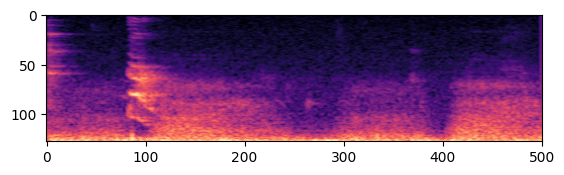

In [7]:
plt.imshow(X_train[2]);

In [8]:
base_model = keras.applications.MobileNetV2(
    include_top=False,
    input_shape=(128, 501, 3),
    weights="imagenet"
)

base_model.trainable = False # freezeo el modelo base

inputs = keras.Input(shape=(128, 501, 3))
traslation_layer = keras.layers.RandomTranslation(height_factor=0, width_factor=0.2, seed=SEED) # augmentacion
flip_layer = keras.layers.RandomFlip("horizontal", seed=SEED) # augmentacion
scale_layer = keras.layers.Rescaling(scale=1 / 127.5, offset=-1) # normalizacion

x = flip_layer(inputs) # augmentacion
x = traslation_layer(x) # augmentacion
x = scale_layer(x) # normalizacion
x = base_model(x, training=False) # inferencia
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dense(256, activation='relu')(x)
x = keras.layers.Dropout(0.3)(x)
x = keras.layers.Dense(64, activation='relu')(x)
x = keras.layers.Dropout(0.2)(x)
outputs = keras.layers.Dense(1, activation='sigmoid')(x)
model = keras.Model(inputs, outputs)

C:\Users\nazar\AppData\Local\Temp\ipykernel_8380\303332731.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


In [9]:
model.summary(show_trainable=True)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1 (InputLayer)  │ (None, 128, 501, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_flip (RandomFlip)    │ (None, 128, 501, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_translation          │ (None, 128, 501, 3)   │          0 │   -   │
│ (RandomTranslation)         │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling (Rescaling)       │ (None, 128, 501, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ mobilenetv2_1.00_224        │ (None, 4, 16, 1280)   │  2,257,984 │   N   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 256)           │    327,936 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 256)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 64)            │     16,448 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_1 (Dropout)         │ (None, 64)            │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_2 (Dense)             │ (None, 1)             │         65 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 2,602,433 (9.93 MB)

 Trainable params: 344,449 (1.31 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
# lr_schedule = keras.optimizers.schedules.PolynomialDecay(
#     initial_learning_rate=1e-3,
#     decay_steps=3000,
#     end_learning_rate=1e-7,
#     power=1.0)

model.compile(
    optimizer=keras.optimizers.Adam(), #learning_rate=lr_schedule),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.AUC(), keras.metrics.Recall()]
)

In [11]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    min_delta=0.001
)

In [12]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - auc: 0.5566 - loss: 0.7251 - recall: 0.5903 - val_auc: 0.6478 - val_loss: 0.6659 - val_recall: 0.7030
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - auc: 0.5728 - loss: 0.6905 - recall: 0.5926 - val_auc: 0.6789 - val_loss: 0.6546 - val_recall: 0.6515
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - auc: 0.6054 - loss: 0.6753 - recall: 0.6297 - val_auc: 0.6953 - val_loss: 0.6623 - val_recall: 0.9182
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - auc: 0.6262 - loss: 0.6658 - recall: 0.6813 - val_auc: 0.7102 - val_loss: 0.6302 - val_recall: 0.5242
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - auc: 0.6338 - loss: 0.6624 - recall: 0.6586 - val_auc: 0.7107 - val_loss: 0.6281 - val_recall: 0.6636
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - auc: 0.6655 - loss: 0.6459 - recall: 0.7003 - val_auc: 0.7348 - val_loss: 0.6284 - val_recall: 0.7818
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - auc: 0.6769 - loss: 0.

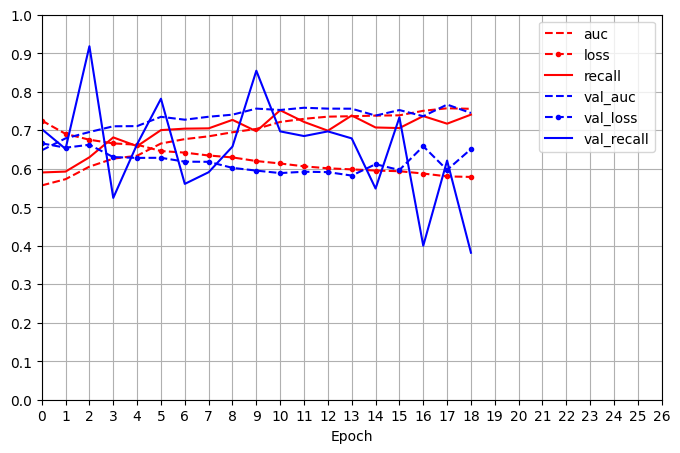

In [13]:
pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 26], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "r-", "b--","b--.", "b-"], xticks=range(0, 27), yticks=np.arange(0, 1.1, 0.1))
plt.show()

In [14]:
model.evaluate(X_test, y_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 23s 711ms/step - auc: 0.7173 - loss: 0.6246 - recall: 0.6971


[0.624584436416626, 0.7173433303833008, 0.6970874071121216]

In [15]:
model.save(f'./neural_network/modelos/ventanas_{dataset}.keras')

## Arrays

In [16]:
train_data = np.load(f'./dataset/ventanas_procesadas/{dataset}/train_melspectrogram.npz')
X_train = train_data['X']
y_train = train_data['y']

test_data = np.load(f'./dataset/ventanas_procesadas/{dataset}/test_melspectrogram.npz')
X_test = test_data['X']
y_test = test_data['y']

In [17]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=SEED
)

In [19]:
X_train = X_train.reshape(-1, 128, 501, 1)
X_val = X_val.reshape(-1, 128, 501, 1)
X_test = X_test.reshape(-1, 128, 501, 1)

In [20]:
X_train = np.repeat(X_train, 3, axis=-1)
X_val = np.repeat(X_val, 3, axis=-1)
X_test = np.repeat(X_test, 3, axis=-1)

In [21]:
base_model = keras.applications.MobileNetV2(
    include_top=False,
    input_shape=(128, 501, 3),
    weights="imagenet"
)
base_model.trainable = False

inputs = keras.Input(shape=(128, 501, 3))
translation_layer = keras.layers.RandomTranslation(height_factor=0, width_factor=0.2, seed=SEED)
flip_layer = keras.layers.RandomFlip("horizontal", seed=SEED)
scale_layer = keras.layers.Rescaling(scale=2/80, offset=1)

x = flip_layer(inputs)
x = translation_layer(x)
x = scale_layer(x)
x = base_model(x, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dense(256, activation='relu')(x)
x = keras.layers.Dropout(0.3)(x)
x = keras.layers.Dense(64, activation='relu')(x)
x = keras.layers.Dropout(0.2)(x)
outputs = keras.layers.Dense(1, activation='sigmoid')(x)

model_melspec = keras.Model(inputs, outputs)

C:\Users\nazar\AppData\Local\Temp\ipykernel_8380\1827241704.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


In [22]:
model_melspec.summary(show_trainable=True)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_3 (InputLayer)  │ (None, 128, 501, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_flip_1 (RandomFlip)  │ (None, 128, 501, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_translation_1        │ (None, 128, 501, 3)   │          0 │   -   │
│ (RandomTranslation)         │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling_1 (Rescaling)     │ (None, 128, 501, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ mobilenetv2_1.00_224        │ (None, 4, 16, 1280)   │  2,257,984 │   N   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d_1  │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_3 (Dense)             │ (None, 256)           │    327,936 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_2 (Dropout)         │ (None, 256)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_4 (Dense)             │ (None, 64)            │     16,448 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_3 (Dropout)         │ (None, 64)            │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_5 (Dense)             │ (None, 1)             │         65 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 2,602,433 (9.93 MB)

 Trainable params: 344,449 (1.31 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [23]:
model_melspec.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.AUC(), keras.metrics.Recall()]
)

In [24]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    min_delta=0.001
)

In [25]:
history_melspec = model_melspec.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - auc_1: 0.5287 - loss: 0.7229 - recall_1: 0.5639 - val_auc_1: 0.6492 - val_loss: 0.6977 - val_recall_1: 0.0400
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - auc_1: 0.5557 - loss: 0.6937 - recall_1: 0.5755 - val_auc_1: 0.6675 - val_loss: 0.6655 - val_recall_1: 0.9247
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - auc_1: 0.6001 - loss: 0.6782 - recall_1: 0.6593 - val_auc_1: 0.6675 - val_loss: 0.6669 - val_recall_1: 0.4682
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - auc_1: 0.6201 - loss: 0.6699 - recall_1: 0.6422 - val_auc_1: 0.6855 - val_loss: 0.6752 - val_recall_1: 0.2000
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - auc_1: 0.6249 - loss: 0.6685 - recall_1: 0.6343 - val_auc_1: 0.6969 - val_loss: 0.6306 - val_recall_1: 0.7153
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - auc_1: 0.6620 - loss: 0.6526 - recall_1: 0.6893 - val_auc_1: 0.7005 - val_loss: 0.6324 - val_recall_1: 0.7129
Epoch 7/50

In [26]:
model_melspec.evaluate(X_test, y_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 24s 735ms/step - auc_1: 0.7633 - loss: 0.5937 - recall_1: 0.6738


[0.5936936736106873, 0.7632532119750977, 0.6737864017486572]

In [27]:
model_melspec.save(f'./neural_network/modelos/ventanas_{dataset}_melspec.keras')